In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

path = "/content/drive/MyDrive/Food Delivery time/dataset/Food Delivery Time Prediction Case Study.xlsx"
df = pd.read_excel(path)

# Drop ID columns
df = df.drop(columns=["ID", "Delivery_person_ID"])

df.head()


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [3]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df["distance_km"] = haversine(
    df["Restaurant_latitude"],
    df["Restaurant_longitude"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"]
)

df[["distance_km", "Time_taken(min)"]].head()


,distance_km,Time_taken(min)
0,3.025149,24
1,20.183530,33
2,1.552758,26
3,7.790401,21
4,6.210138,30


In [4]:
df["distance_km"].describe()

,distance_km
count,45593.000000
mean,99.303911
std,1099.731281
min,1.465067
25%,4.663493
50%,9.264281
75%,13.763977
max,19692.674606


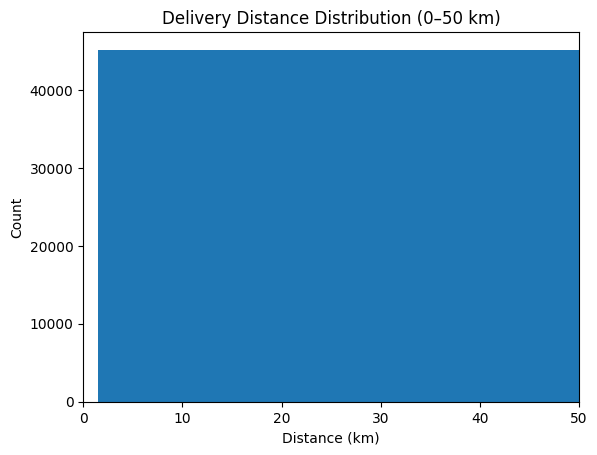

In [5]:
import matplotlib.pyplot as plt

plt.hist(df["distance_km"], bins=100)
plt.xlim(0, 50)
plt.xlabel("Distance (km)")
plt.ylabel("Count")
plt.title("Delivery Distance Distribution (0–50 km)")
plt.show()


In [6]:
df = df[df["distance_km"] <= 30].reset_index(drop=True)

df["distance_km"].describe()


,distance_km
count,45162.000000
mean,9.735396
std,5.608508
min,1.465067
25%,4.663412
50%,9.220209
75%,13.681490
max,20.969489


In [7]:
X = df.drop(columns=["Time_taken(min)"])
y = df["Time_taken(min)"]


In [8]:
X = pd.get_dummies(
    X,
    columns=["Type_of_order", "Type_of_vehicle"],
    drop_first=True
)


In [10]:
X.shape


(45162, 13)

In [11]:
X.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,distance_km,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
0,37,4.9,22.745049,75.892471,22.765049,75.912471,3.025149,False,False,True,False,True,False
1,34,4.5,12.913041,77.683237,13.043041,77.813237,20.183530,False,False,True,False,False,True
2,23,4.4,12.914264,77.678400,12.924264,77.688400,1.552758,True,False,False,False,True,False
3,38,4.7,11.003669,76.976494,11.053669,77.026494,7.790401,False,False,False,False,True,False
4,32,4.6,12.972793,80.249982,13.012793,80.289982,6.210138,False,False,True,False,False,True


In [13]:
save_path = "/content/drive/MyDrive/Food Delivery time/clean_data.csv"

clean_df = X.copy()
clean_df["Time_taken(min)"] = y.values

clean_df.to_csv(save_path, index=False)

print("Saved at:", save_path)


Saved at: /content/drive/MyDrive/Food Delivery time/clean_data.csv
